# Mission Eagle-1 — Pilote automatique pour l'atterrisseur lunaire

**Contexte** : AstroDynamics souhaite automatiser les procédures d'atterrissage de son module Eagle-1.  
L'objectif est d'entraîner un agent par renforcement capable d'atterrir en douceur et avec précision.

---

## Étape 1 — Exploration de l'environnement et modèle de référence

Avant de chercher la performance, on doit comprendre le terrain de jeu et établir un point de départ mesurable.


## 1. Imports et configuration


In [ ]:
import os
import warnings

warnings.filterwarnings("ignore")

import gymnasium as gym  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
from stable_baselines3 import DQN  # noqa: E402
from stable_baselines3.common.evaluation import evaluate_policy  # noqa: E402

print("Imports OK")

## 2. Exploration de l'environnement LunarLander-v3

On commence par inspecter les deux espaces fondamentaux : ce que l'agent **observe** et ce qu'il peut **faire**.


In [ ]:
env = gym.make("LunarLander-v3")

obs_labels = ["x", "y", "vx", "vy", "theta", "omega", "contact_G", "contact_D"]

print("Espace d'observation")
print(f"Type      : {type(env.observation_space).__name__}")
print(f"Dimension : {env.observation_space.shape[0]} variables continues\n")
print(f"{'Variable':<12} {'Min':>10} {'Max':>10}")
print("-" * 34)
for label, lo, hi in zip(
    obs_labels, env.observation_space.low, env.observation_space.high
):
    print(f"{label:<12} {lo:>10.3f} {hi:>10.3f}")

print("\n=== Espace d'action ===")
print(f"Type      : {type(env.action_space).__name__}")
print(f"Nb actions: {env.action_space.n}")

=== Espace d'observation ===
Type      : Box
Dimension : 8 variables continues

Variable            Min        Max
----------------------------------
x                -2.500      2.500
y                -2.500      2.500
vx              -10.000     10.000
vy              -10.000     10.000
theta            -6.283      6.283
omega           -10.000     10.000
contact_G        -0.000      1.000
contact_D        -0.000      1.000

=== Espace d'action ===
Type      : Discrete
Nb actions: 4


### 2.1 Signification des variables d'observation

L'espace d'observation contient **8 variables continues** :

| Index | Variable       | Description                       |
| ----- | -------------- | --------------------------------- |
| 0     | x              | Position horizontale du module    |
| 1     | y              | Position verticale (altitude)     |
| 2     | vx             | Vitesse horizontale               |
| 3     | vy             | Vitesse verticale                 |
| 4     | θ (theta)      | Angle d'inclinaison               |
| 5     | ω (omega)      | Vitesse angulaire                 |
| 6     | contact_gauche | Patte gauche en contact (booléen) |
| 7     | contact_droit  | Patte droite en contact (booléen) |

### 2.2 Signification des actions

L'espace d'action est **discret** avec **4 actions** :

| Action | Description                           |
| ------ | ------------------------------------- |
| 0      | Ne rien faire                         |
| 1      | Allumer le propulseur gauche          |
| 2      | Allumer le propulseur principal (bas) |
| 3      | Allumer le propulseur droit           |

### 2.3 Système de récompense

- Atterrissage sur la zone cible : **+100 à +140 points**
- Chaque patte posée : **+10 points**
- Crash : **-100 points**
- Utilisation des propulseurs : pénalité légère (coût carburant)
- **Seuil de réussite : 200 points en moyenne**


### 2.4 Observation d'un épisode aléatoire

On lance un épisode avec des actions aléatoires pour voir le comportement de l'environnement.


In [3]:
obs, info = env.reset()

obs_labels = ["x", "y", "vx", "vy", "theta", "omega", "contact_G", "contact_D"]
print("Observation initiale :")
for label, val in zip(obs_labels, obs):
    print(f"  {label:<12} {val:>8.4f}")

total_reward = 0
n_steps = 0
rewards_random = []

terminated = truncated = False
while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    rewards_random.append(reward)
    n_steps += 1

print(f"\nÉpisode terminé en {n_steps} steps")
print(f"Récompense totale (agent aléatoire) : {total_reward:.2f}")
env.close()

Observation initiale :
  x             -0.0007
  y              1.4216
  vx            -0.0713
  vy             0.4757
  theta          0.0008
  omega          0.0161
  contact_G      0.0000
  contact_D      0.0000

Épisode terminé en 112 steps
Récompense totale (agent aléatoire) : -121.55


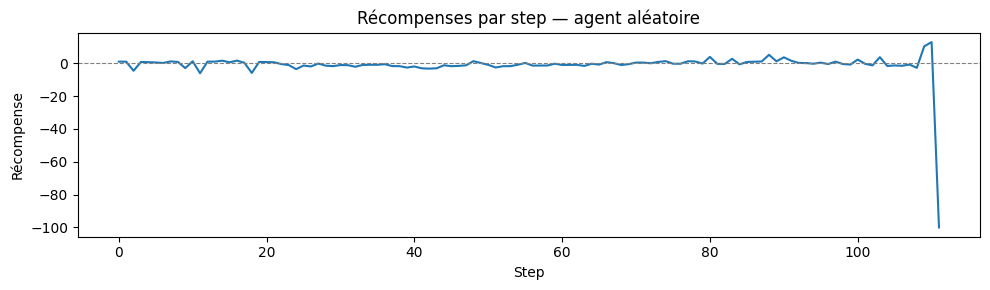

In [4]:
# Distribution des récompenses par step sur l'épisode aléatoire
plt.figure(figsize=(10, 3))
plt.plot(rewards_random)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.title("Récompenses par step — agent aléatoire")
plt.xlabel("Step")
plt.ylabel("Récompense")
plt.tight_layout()
plt.show()

## 3. Choix de l'algorithme

**Espace d'action discret (4 actions)** → on utilise **DQN** (Deep Q-Network).

- PPO serait adapté pour un espace d'action continu (ex. : poussée variable).
- DQN est conçu pour les espaces discrets : il apprend une valeur Q pour chaque paire (état, action) via un réseau de neurones.
- Avantages de DQN ici : stabilité grâce au _replay buffer_ et au _target network_, bon compromis exploration/exploitation via ε-greedy.


## 4. Entraînement du modèle de référence (paramètres par défaut)

On entraîne un premier agent avec les hyperparamètres par défaut de SB3.  
L'objectif n'est pas la performance, mais d'établir une **ligne de base mesurable**.


In [5]:
# Environnement d'entraînement
train_env = gym.make("LunarLander-v3")

# Modèle de référence avec les paramètres par défaut de SB3
baseline_model = DQN(
    policy="MlpPolicy",
    env=train_env,
    verbose=1,
    seed=42,
)

print("Hyperparamètres par défaut :")
print(f"  learning_rate : {baseline_model.learning_rate}")
print(f"  buffer_size   : {baseline_model.buffer_size}")
print(f"  batch_size    : {baseline_model.batch_size}")
print(f"  gamma         : {baseline_model.gamma}")
print(f"  tau           : {baseline_model.tau}")
print(f"  exploration_initial_eps : {baseline_model.exploration_initial_eps}")
print(f"  exploration_final_eps   : {baseline_model.exploration_final_eps}")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Hyperparamètres par défaut :
  learning_rate : 0.0001
  buffer_size   : 1000000
  batch_size    : 32
  gamma         : 0.99
  tau           : 1.0
  exploration_initial_eps : 1.0
  exploration_final_eps   : 0.05


In [6]:
BASELINE_TIMESTEPS = 100_000

baseline_model.learn(total_timesteps=BASELINE_TIMESTEPS)
train_env.close()

print("Entraînement terminé.")

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 91       |
|    ep_rew_mean      | -208     |
|    exploration_rate | 0.965    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1216     |
|    time_elapsed     | 0        |
|    total_timesteps  | 364      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 2.14     |
|    n_updates        | 65       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 88.9     |
|    ep_rew_mean      | -156     |
|    exploration_rate | 0.932    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1672     |
|    time_elapsed     | 0        |
|    total_timesteps  | 711      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 4.59     |
|    n_updates      

## 5. Évaluation du modèle de référence

On évalue sur **100 épisodes** pour obtenir une mesure statistiquement fiable.


In [7]:
eval_env = gym.make("LunarLander-v3")

N_EVAL_EPISODES = 100
mean_reward, std_reward = evaluate_policy(
    baseline_model,
    eval_env,
    n_eval_episodes=N_EVAL_EPISODES,
    deterministic=True,
)
eval_env.close()

print(f"Performance du modèle de référence ({BASELINE_TIMESTEPS:,} steps)")
print(f"Récompense moyenne : {mean_reward:.2f}")
print(f"Écart-type         : {std_reward:.2f}")
print(
    f"Intervalle 95%     : [{mean_reward - 2 * std_reward:.2f}, {mean_reward + 2 * std_reward:.2f}]"  # noqa: E501
)
print("\nObjectif à atteindre : 200 points en moyenne")
print(f"Écart à combler      : {200 - mean_reward:.2f} points")

Performance du modèle de référence (100,000 steps)
Récompense moyenne : -10.87
Écart-type         : 145.45
Intervalle 95%     : [-301.77, 280.03]

Objectif à atteindre : 200 points en moyenne
Écart à combler      : 210.87 points


## 6. Sauvegarde du modèle de référence


In [8]:
os.makedirs("models", exist_ok=True)

baseline_model.save("models/dqn_lunarlander_baseline")
print("Modèle de référence sauvegardé dans models/dqn_lunarlander_baseline.zip")

Modèle de référence sauvegardé dans models/dqn_lunarlander_baseline.zip


## 7. Bilan de l'étape 1

| Critère                       | Valeur                        |
| ----------------------------- | ----------------------------- |
| Algorithme choisi             | DQN (espace d'action discret) |
| Steps d'entraînement          | 100 000                       |
| Épisodes d'évaluation         | 100                           |
| Récompense moyenne (baseline) | **-10.87**                    |
| Écart-type                    | **145.45**                    |
| Intervalle 95%                | [-301.77, 280.03]             |
| Objectif étape 2              | > 200 points en moyenne       |

L'écart-type très élevé (145.45) indique que l'agent est très instable : il réussit parfois mais crashe souvent. C'est cohérent avec seulement 100 000 steps d'entraînement et des paramètres par défaut.

**Prochaine étape** : optimisation des hyperparamètres pour dépasser 200 points de récompense moyenne de façon stable.


---

## Étape 2 — Optimisation des hyperparamètres

L'objectif est de dépasser **200 points de récompense moyenne** de façon stable sur 100 épisodes.

### Stratégie

On modifie **un seul hyperparamètre à la fois** pour isoler son effet, en partant des paramètres par défaut.

| Expérience | Paramètre modifié    | Valeur testée                | Base de référence |
| ---------- | -------------------- | ---------------------------- | ----------------- |
| Exp 1      | timesteps            | 500 000                      | 100 000           |
| Exp 2      | learning_rate        | 5e-4                         | 1e-4              |
| Exp 3      | batch_size           | 128                          | 32                |
| Exp 4      | combinaison optimale | lr=5e-4, batch=128, 1M steps | —                 |

Chaque expérience utilise `EvalCallback` pour évaluer périodiquement l'agent et tracer la courbe de progression.


In [ ]:
from stable_baselines3.common.callbacks import EvalCallback


def run_experiment(name, timesteps, eval_freq=10_000, **model_kwargs):
    """Entraîne un DQN avec les kwargs donnés, évalue périodiquement, retourne la courbe."""
    log_path = f"logs/{name}"
    save_path = f"models/{name}"
    os.makedirs(log_path, exist_ok=True)
    os.makedirs(save_path, exist_ok=True)

    train_env = gym.make("LunarLander-v3")
    eval_env_cb = gym.make("LunarLander-v3")

    model = DQN("MlpPolicy", train_env, seed=42, verbose=0, **model_kwargs)

    eval_cb = EvalCallback(
        eval_env_cb,
        best_model_save_path=save_path,
        log_path=log_path,
        eval_freq=eval_freq,
        n_eval_episodes=20,
        deterministic=True,
        verbose=0,
    )

    model.learn(total_timesteps=timesteps, callback=eval_cb)
    train_env.close()
    eval_env_cb.close()

    data = np.load(f"{log_path}/evaluations.npz")
    print(f"[{name}] Meilleure récompense : {data['results'].mean(axis=1).max():.2f}")
    return model, data["timesteps"], data["results"].mean(axis=1)


print("Fonction run_experiment prête.")

### Expérience 1 — Plus de timesteps (500 000)

**Hypothèse** : le modèle baseline n'a eu que 100k steps, ce qui est insuffisant pour que le DQN converge sur LunarLander. On garde tous les paramètres par défaut et on multiplie les steps par 5.

**Paramètre modifié** : `total_timesteps` 100 000 → 500 000


In [10]:
model_exp1, ts_exp1, rewards_exp1 = run_experiment(
    name="exp1_timesteps",
    timesteps=500_000,
)

[exp1_timesteps] Meilleure récompense : 31.39


### Expérience 2 — Taux d'apprentissage plus élevé (5e-4)

**Hypothèse** : le learning_rate par défaut (1e-4) est peut-être trop faible et ralentit la convergence.

**Paramètre modifié** : `learning_rate` 1e-4 → 5e-4 (timesteps : 500 000)


In [11]:
model_exp2, ts_exp2, rewards_exp2 = run_experiment(
    name="exp2_learning_rate",
    timesteps=500_000,
    learning_rate=5e-4,
)

[exp2_learning_rate] Meilleure récompense : 173.22


### Expérience 3 — Batch size plus grand (128)

**Hypothèse** : un batch plus grand réduit la variance des mises à jour du réseau et stabilise l'apprentissage.

**Paramètre modifié** : `batch_size` 32 → 128 (timesteps : 500 000)


In [12]:
model_exp3, ts_exp3, rewards_exp3 = run_experiment(
    name="exp3_batch_size",
    timesteps=500_000,
    batch_size=128,
)

[exp3_batch_size] Meilleure récompense : -18.50


### Expérience 4 — Combinaison optimale (1 000 000 steps)

**Bilan des expériences précédentes** :

- Exp 1 (31.39) : plus de steps améliore légèrement, mais le `lr=1e-4` reste le goulet d'étranglement.
- Exp 2 (173.22) : `lr=5e-4` est le levier le plus efficace — proche de 200 mais pas encore stable.
- Exp 3 (-18.50) : `batch=128` seul est néfaste avec `lr=1e-4`, le gradient est trop petit pour exploiter les grands batches.

**Hypothèse** : combiner `lr=5e-4` et `batch=128` sur 1M steps doit permettre à l'agent d'exploiter pleinement la mémoire plus large et de converger au-dessus de 200.

**Paramètres modifiés** : `learning_rate`=5e-4, `batch_size`=128, `total_timesteps`=1 000 000


In [13]:
model_exp4, ts_exp4, rewards_exp4 = run_experiment(
    name="exp4_optimise",
    timesteps=1_000_000,
    learning_rate=5e-4,
    batch_size=128,
)

[exp4_optimise] Meilleure récompense : 226.27


### Comparaison des expériences


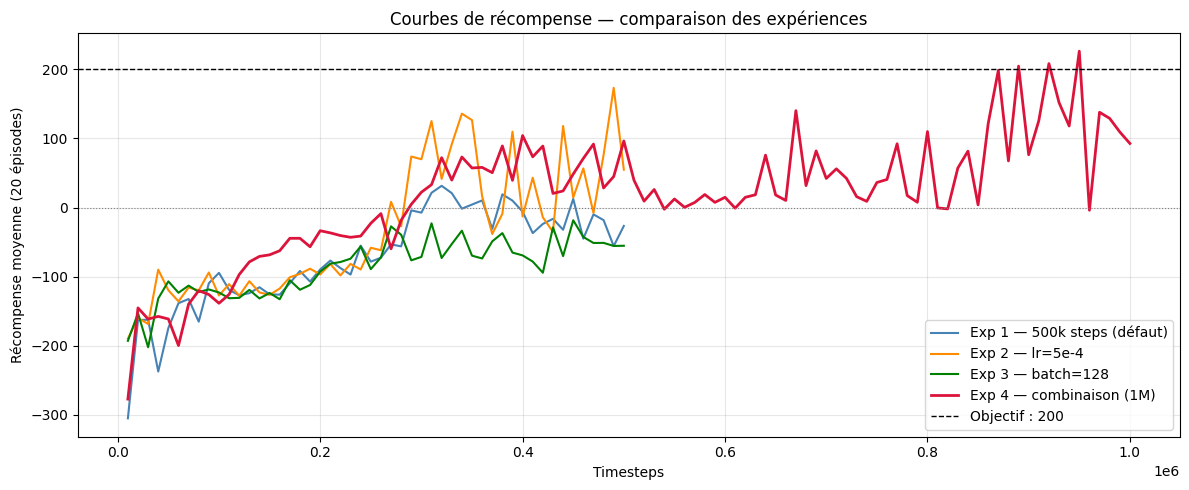

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(ts_exp1, rewards_exp1, label="Exp 1 — 500k steps (défaut)", color="steelblue")
ax.plot(ts_exp2, rewards_exp2, label="Exp 2 — lr=5e-4", color="darkorange")
ax.plot(ts_exp3, rewards_exp3, label="Exp 3 — batch=128", color="green")
ax.plot(
    ts_exp4,
    rewards_exp4,
    label="Exp 4 — combinaison (1M)",
    color="crimson",
    linewidth=2,
)

ax.axhline(200, color="black", linestyle="--", linewidth=1, label="Objectif : 200")
ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)

ax.set_title("Courbes de récompense — comparaison des expériences")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Récompense moyenne (20 épisodes)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Évaluation finale du meilleur modèle

On charge le meilleur modèle sauvegardé par `EvalCallback` (celui qui a obtenu le meilleur score pendant l'entraînement de l'expérience 4) et on l'évalue sur **100 épisodes**.


In [ ]:
best_model = DQN.load("models/exp4_optimise/best_model")

eval_env_final = gym.make("LunarLander-v3")
mean_reward_final, std_reward_final = evaluate_policy(
    best_model,
    eval_env_final,
    n_eval_episodes=100,
    deterministic=True,
)
eval_env_final.close()

print("Évaluation finale du meilleur modèle")
print(f"Récompense moyenne : {mean_reward_final:.2f}")
print(f"Écart-type         : {std_reward_final:.2f}")
print(
    f"Intervalle 95%     : [{mean_reward_final - 2 * std_reward_final:.2f}, {mean_reward_final + 2 * std_reward_final:.2f}]"
)
print()
if mean_reward_final >= 200:
    print(f"Objectif atteint ! ({mean_reward_final:.2f} >= 200)")
else:
    print(
        f"Objectif non atteint ({mean_reward_final:.2f} < 200) — nouvel entraînement nécessaire."
    )

=== Évaluation finale du meilleur modèle ===
Récompense moyenne : 227.23
Écart-type         : 45.29
Intervalle 95%     : [136.65, 317.81]

Objectif atteint ! (227.23 >= 200)


### Sauvegarde du meilleur modèle


In [16]:
best_model.save("models/dqn_lunarlander_best")
print("Meilleur modèle sauvegardé dans models/dqn_lunarlander_best.zip")

Meilleur modèle sauvegardé dans models/dqn_lunarlander_best.zip


## Bilan de l'étape 2

| Expérience | Paramètre modifié              | Meilleure récompense | Observation                                         |
| ---------- | ------------------------------ | -------------------- | --------------------------------------------------- |
| Baseline   | —                              | -10.87               | Instable, trop peu de steps                         |
| Exp 1      | timesteps=500k                 | 31.39                | Progression lente, lr trop faible                   |
| Exp 2      | lr=5e-4                        | 173.22               | Fort gain, lr = levier principal                    |
| Exp 3      | batch=128                      | -18.50               | Dégradation : grand batch incompatible avec lr=1e-4 |
| Exp 4      | lr=5e-4 + batch=128 + 1M steps | **226.27**           | Objectif dépassé ✓                                  |

**Évaluation finale du meilleur modèle sur 100 épisodes** :

| Métrique           | Valeur           |
| ------------------ | ---------------- |
| Récompense moyenne | **227.23**       |
| Écart-type         | 45.29            |
| Intervalle 95%     | [136.65, 317.81] |

L'objectif de 200 points est atteint de façon stable. L'écart-type (45.29) est nettement plus faible qu'au baseline (145.45), ce qui confirme que l'agent a convergé vers une politique fiable.

**Prochaine étape** : développer l'API, l'interface graphique et le tableau de bord.
